In [23]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#Loading the file
df=pd.read_csv('UberDataset.csv')
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


EDA

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [26]:
#Removing the unwanted rows
df.drop(df.index[1155],inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [27]:
df.drop_duplicates(inplace=True)     #Removing duplicate rows
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1154 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1154 non-null   object 
 1   END_DATE    1154 non-null   object 
 2   CATEGORY    1154 non-null   object 
 3   START       1154 non-null   object 
 4   STOP        1154 non-null   object 
 5   MILES       1154 non-null   float64
 6   PURPOSE     652 non-null    object 
dtypes: float64(1), object(6)
memory usage: 72.1+ KB


In [28]:
df.shape

(1154, 7)

In [29]:
#Resetting the index
df.reset_index(inplace=True)
df.drop('index',axis=1,inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1150,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1151,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1152,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [30]:
df.isnull().sum()

,0
START_DATE,0
END_DATE,0
CATEGORY,0
START,0
STOP,0
MILES,0
PURPOSE,502


In [31]:
#Cleaning PURPOSE column
df['PURPOSE']=df['PURPOSE'].fillna('Unknown')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1154 entries, 0 to 1153
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1154 non-null   object 
 1   END_DATE    1154 non-null   object 
 2   CATEGORY    1154 non-null   object 
 3   START       1154 non-null   object 
 4   STOP        1154 non-null   object 
 5   MILES       1154 non-null   float64
 6   PURPOSE     1154 non-null   object 
dtypes: float64(1), object(6)
memory usage: 63.2+ KB


In [32]:
df.isnull().sum()

,0
START_DATE,0
END_DATE,0
CATEGORY,0
START,0
STOP,0
MILES,0
PURPOSE,0


In [33]:
df["START_DATE"].unique()

array(['01-01-2016 21:11', '01-02-2016 01:25', '01-02-2016 20:25', ...,
       '12/31/2016 15:03', '12/31/2016 21:32', '12/31/2016 22:08'],
      dtype=object)

In [34]:
df["END_DATE"].unique()

array(['01-01-2016 21:17', '01-02-2016 01:37', '01-02-2016 20:38', ...,
       '12/31/2016 15:38', '12/31/2016 21:50', '12/31/2016 23:51'],
      dtype=object)

In [35]:
df['START_DATE']=df['START_DATE'].str.replace('/','-')
df['END_DATE']=df['END_DATE'].str.replace('/','-')


df['START_DATE']=pd.to_datetime(df['START_DATE'])
df['END_DATE']=pd.to_datetime(df['END_DATE'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1154 entries, 0 to 1153
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[ns]
 1   END_DATE    1154 non-null   datetime64[ns]
 2   CATEGORY    1154 non-null   object        
 3   START       1154 non-null   object        
 4   STOP        1154 non-null   object        
 5   MILES       1154 non-null   float64       
 6   PURPOSE     1154 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.2+ KB


In [36]:
#Converting the date and time to Morning, Afternoon, Evening, Night
df['DATE']=pd.DatetimeIndex(df['START_DATE']).date
df['TIME']=pd.DatetimeIndex(df['START_DATE']).hour

out=[]
for i in df['TIME']:
  if 0<=i<=10:
    out.append('Morning')
  elif 11<=i<=15:
    out.append('Afternoon')
  elif 16<=i<=19:
    out.append('Evening')
  elif 20<=i<=24:
    out.append('Night')
df['DAY-NIGHT']=out
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon
...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,2016-12-31,1,Morning
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,2016-12-31,13,Afternoon
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,Afternoon
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,Night


In [37]:
#Month column
df['MONTH']=[i.month for i in df['START_DATE']]
df['MONTH']=df['MONTH'].map({1:'JAN',  2:'FEB',  3:'MAR',  4:'APR',  5:'MAY',  6:'JUN',  7:'JUL',  8:'AUG',  9:'SEP', 10:'OCT', 11:'NOV', 12:'DEC'})
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,JAN
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,Morning,JAN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night,JAN
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,JAN
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,JAN
...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,2016-12-31,1,Morning,DEC
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,2016-12-31,13,Afternoon,DEC
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,Afternoon,DEC
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,Night,DEC


In [38]:
#Day column
df['DAY']=df['START_DATE'].dt.weekday
df['DAY']=df['DAY'].map({0:'MON',1:'TUE',2:'WED',3:'THU',4:'FRI',5:'SAT',6:'SUN'})
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAY-NIGHT,MONTH,DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night,JAN,FRI
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,Morning,JAN,SAT
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night,JAN,SAT
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening,JAN,TUE
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,JAN,WED
...,...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,2016-12-31,1,Morning,DEC,SAT
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,2016-12-31,13,Afternoon,DEC,SAT
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,Afternoon,DEC,SAT
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,Night,DEC,SAT


In [39]:
#Changing the specific data in a column
df['START']=df['START'].str.replace('Kar?chi','Karachi')
df['STOP']=df['STOP'].str.replace('Kar?chi','Karachi')

Data Visualization

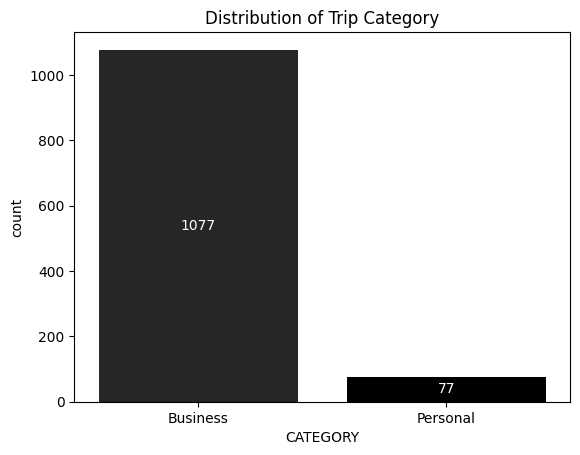

In [41]:
a = sns.countplot(x='CATEGORY', data=df, hue='CATEGORY', palette='dark:black')
plt.title("Distribution of Trip Category")

def data_label(a):
    for i in a.containers:
        a.bar_label(i, label_type='center', color='white')

data_label(a)

**Interpretation:**
Most trips belong to the Business category (1077), while Personal trips (77) are very few.

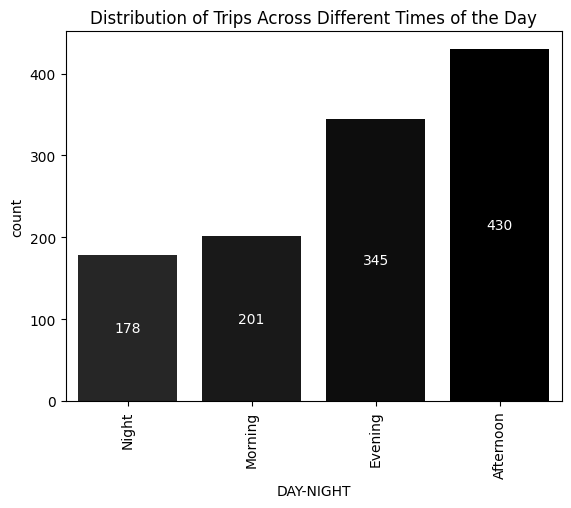

In [43]:
a=sns.countplot(x='DAY-NIGHT',data=df,hue='DAY-NIGHT',palette='dark:black')
data_label(a)
plt.title("Distribution of Trips Across Different Times of the Day")
plt.xticks(rotation=90)
plt.show()

**Interpretation:** Most trips occur in the Afternoon (430) followed by Evening (345), while Night (178) has the fewest trips.

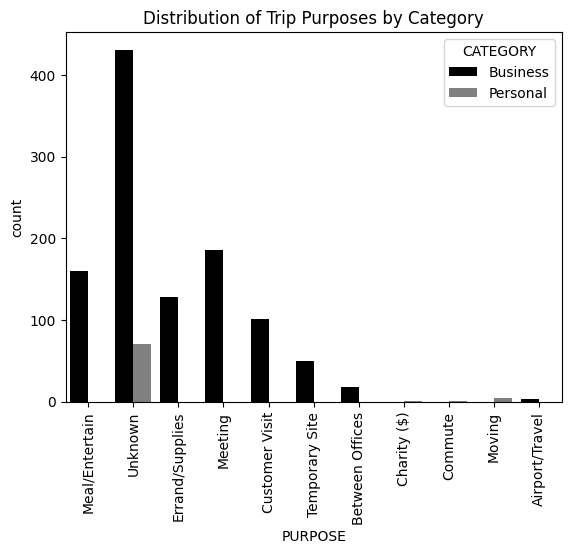

In [45]:
uber_palette = sns.color_palette(["black","gray"])
a=sns.countplot(x='PURPOSE',data=df,hue='CATEGORY',palette=uber_palette)
plt.title("Distribution of Trip Purposes by Category")
plt.xticks(rotation=90)
plt.show()

**Interpretation:** Most trips are for unknown purposes, followed by meetings and meals/entertainment, and the majority of these trips fall under the Business category rather than Personal.

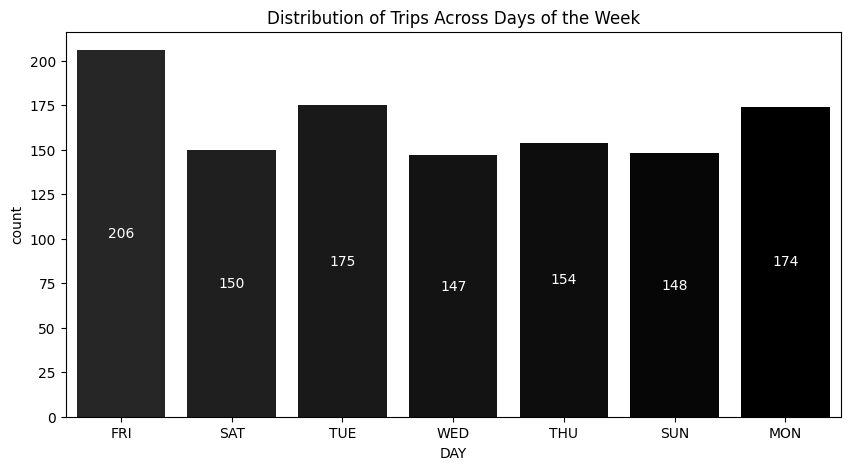

In [47]:
plt.figure(figsize=(10,5))
a=sns.countplot(x='DAY',data=df,hue='DAY',palette='dark:black')
plt.title("Distribution of Trips Across Days of the Week")
data_label(a)
plt.show()

**Interpretation:** Trips are highest on Friday (206) and lowest on Wednesday (147), while the number of trips on other days is fairly similar.

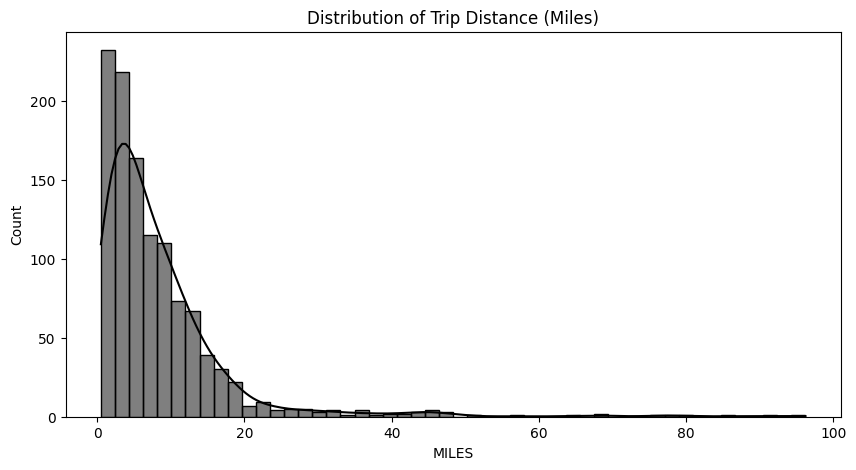

In [49]:
plt.figure(figsize=(10,5))
sns.histplot(x='MILES',data=df[df['MILES']<100],kde=True,bins=50,color='black')
plt.title("Distribution of Trip Distance (Miles)")
plt.show()

**Interpretation:** Most trips cover short distances (below ~10 miles), and the distribution is right-skewed, indicating fewer long-distance trips.

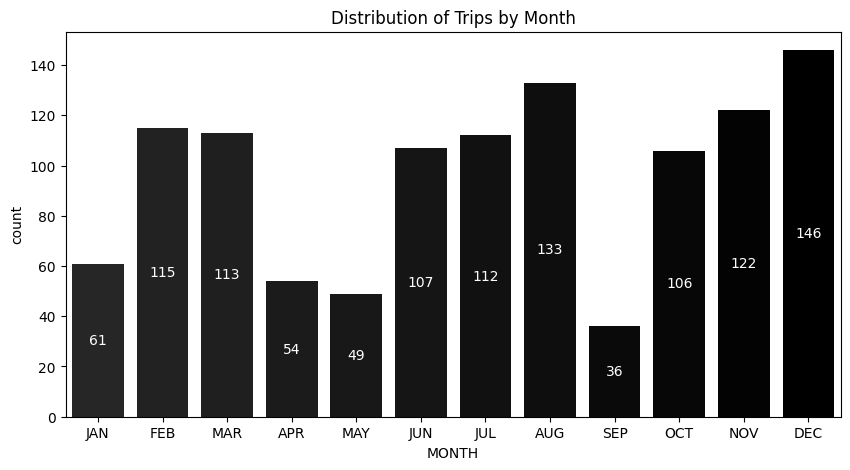

In [51]:
plt.figure(figsize=(10,5))
a=sns.countplot(x='MONTH',data=df,hue='MONTH',palette='dark:black')
plt.title("Distribution of Trips by Month")
data_label(a)
plt.show()

**Interpretation:** Trips are highest in December (146) and August (133) and lowest in September (36), showing variation in trip frequency across months.

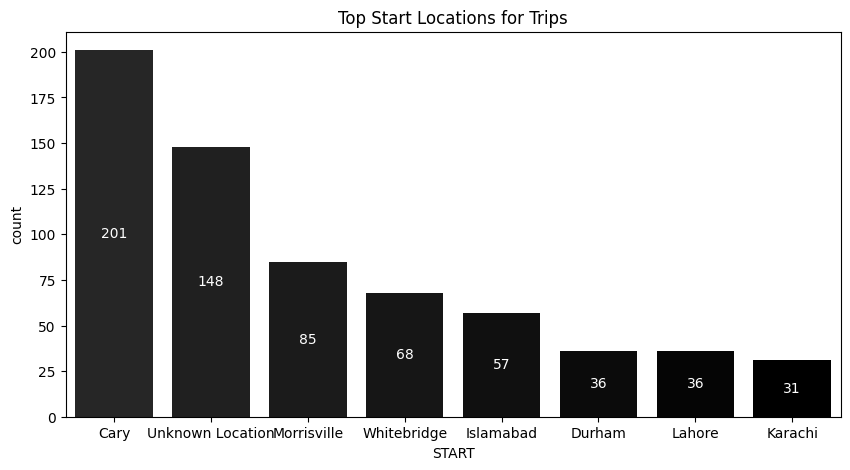

In [53]:
df1=pd.DataFrame(df['START'].value_counts())
plt.figure(figsize=(10,5))
a=sns.barplot(x='START',y='count',data=df1[df1['count']>30],hue='START',palette='dark:black')
plt.title("Top Start Locations for Trips")
data_label(a)

**Interpretation:** Most trips start from Cary (201) followed by Unknown Location (148), while other locations have significantly fewer trip counts.

**Insights:**
1. Most cab trips originate from the Cary location, making it the most common
starting point.

2. A large number of cab bookings occur during the afternoon period.

3. Cab bookings are very rare for distances greater than 20 miles.

4. The highest number of bookings occur in February, March, August, November, and December.

5. Many users prefer cabs for short trips between 0 and 20 miles.

6. A significant portion of cab rides are taken for business purposes, meals/entertainment, and meetings.

7. The most common travel distance is around 4–5 miles.

8. Cab bookings are comparatively higher on Friday, Tuesday, and Monday.
